In [1]:
import pandas as pd
import matplotlib.pyplot as plt

movies = pd.read_csv("../dataset/tmdb/tmdb_5000_movies.csv")
credits = pd.read_csv("../dataset/tmdb/tmdb_5000_credits.csv")

movies = movies.merge(credits, left_on="id", right_on="movie_id")

In [2]:
print(movies.shape,
movies.info(),
movies.describe())

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [3]:
print(movies.isnull().sum())

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title_x                    0
vote_average               0
vote_count                 0
movie_id                   0
title_y                    0
cast                       0
crew                       0
dtype: int64


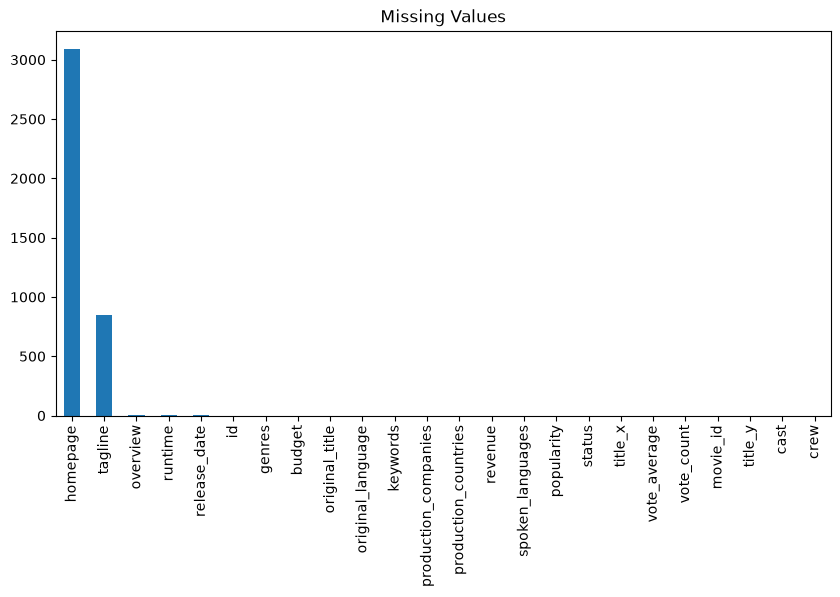

In [4]:
movies.isnull().sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Missing Values")
plt.show()

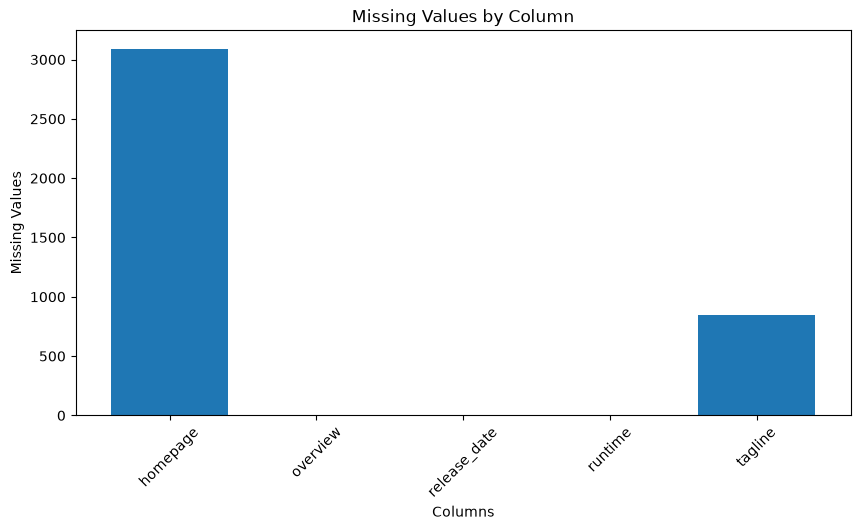

In [5]:
missing = movies.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10,5))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=45)
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.show()

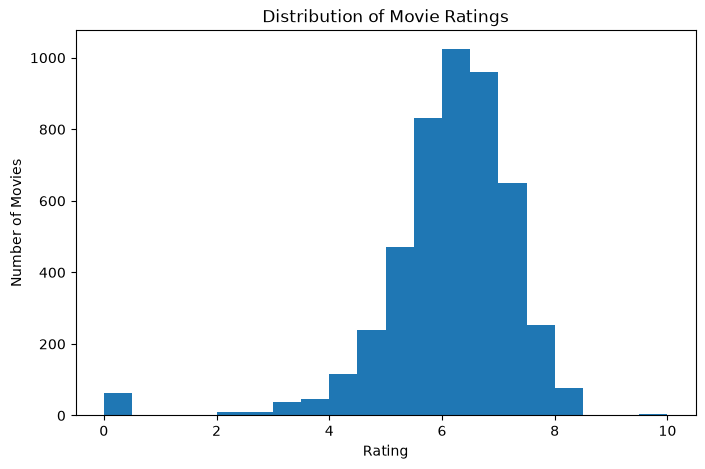

In [6]:
plt.figure(figsize=(8,5))
plt.hist(movies['vote_average'], bins=20)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

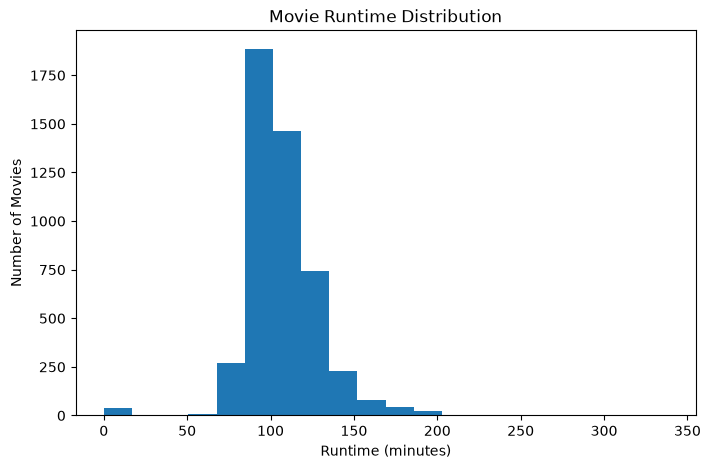

In [7]:
plt.figure(figsize=(8,5))
plt.hist(movies['runtime'].dropna(), bins=20)
plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")
plt.show()

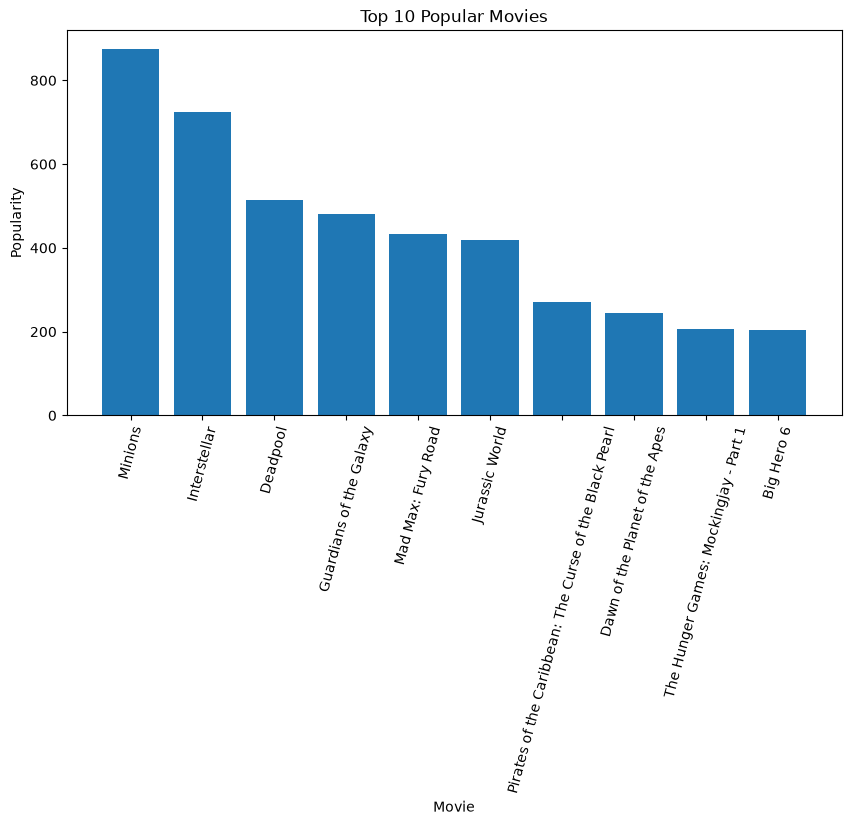

In [8]:
top_popular = movies.sort_values(by="popularity", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_popular['title_x'], top_popular['popularity'])
plt.xticks(rotation=75)
plt.title("Top 10 Popular Movies")
plt.xlabel("Movie")
plt.ylabel("Popularity")
plt.show()

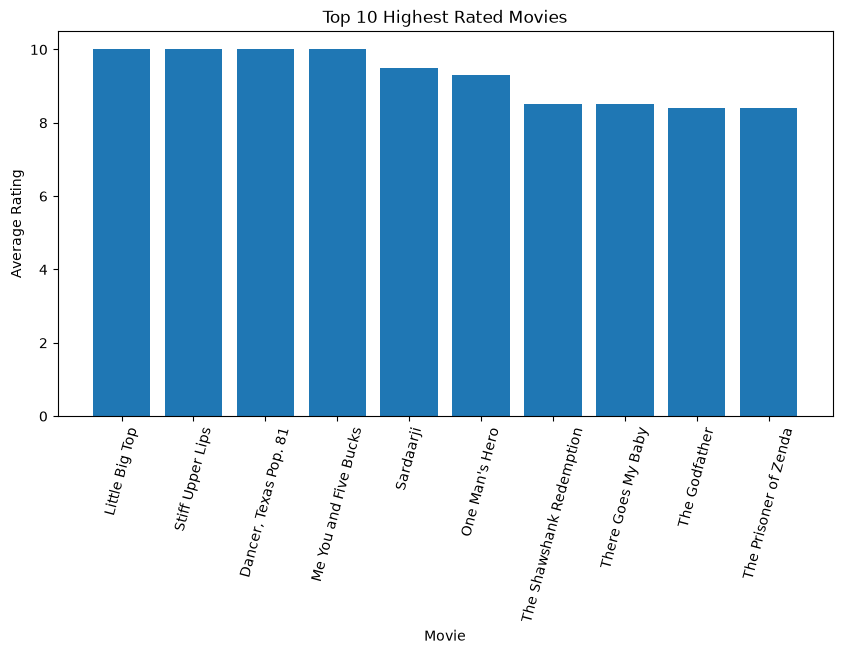

In [9]:
top_rated = movies.sort_values(by="vote_average", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_rated['title_x'], top_rated['vote_average'])
plt.xticks(rotation=75)
plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Movie")
plt.ylabel("Average Rating")
plt.show()

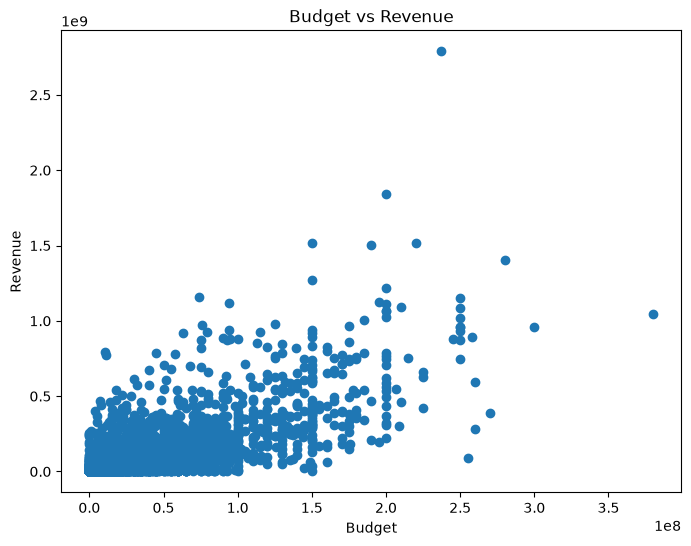

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(movies['budget'], movies['revenue'])
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

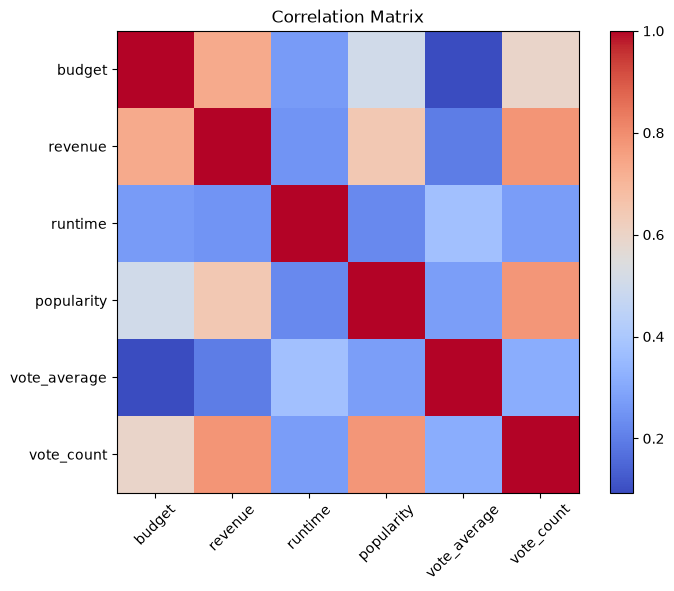

In [11]:
numeric = movies[['budget','revenue','runtime','popularity','vote_average','vote_count']]

corr = numeric.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()